# Phase 6: Time-Series Cross-Validation
---

**Purpose:** Validate NB-AR model robustness using 5-fold expanding-window time-series cross-validation. This preserves temporal ordering (training data always precedes test data).  

**Note on prediction post-processing:** Cross-validation uses raw, unmodified model predictions the same evaluation protocol as Phase 5. No clipping or capping is applied, so CV and single-split results are directly comparable. When the exponential link of an NB model combined with autoregressive terms produces a numerical excursion in a particular fold, this is reported transparently as a diagnostic signal rather than masked.

**Input:** `phase2b_output_with_lags.csv`

## 6.1 Setup

In [1]:
!pip install -q statsmodels scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

## 6.2 Load Data

In [2]:
print('Upload: phase2b_output_with_lags.csv')
uploaded = files.upload()
data_file = list(uploaded.keys())[0]
df = pd.read_csv(data_file)
print(f'Loaded: {len(df):,} records, MOH: {sorted(df["MOH"].unique())}')

# Verify required columns exist (aligned with standardised naming from Phase 2 / 2b)
required = ['MOH','Year','Week','Dengue_Cases','Weekly_Mean_Rainfall',
            'Rainfall_Lag4','Rainfall_Lag6','Dengue_Lag1','Dengue_Lag2']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

df_clean = df.dropna(subset=['Rainfall_Lag4','Dengue_Lag1','Dengue_Lag2']).copy()
print(f'Clean data: {len(df_clean):,} records')

Upload: phase2b_output_with_lags.csv


Saving phase2b_output_with_lags (10).csv to phase2b_output_with_lags (10).csv
Loaded: 520 records, MOH: ['Balangoda', 'Udawalawa']
Clean data: 512 records


## 6.3 Five-Fold Expanding-Window Cross-Validation

In [3]:
# Cross-validation — NO clipping: raw NB-AR predictions evaluated directly,
# keeping methodology consistent with the single-split evaluation in Phase 5.
N_SPLITS = 5
cv_results = []

for moh in sorted(df_clean['MOH'].unique()):
    print(f'\n→ {moh}:')
    moh_data = df_clean[df_clean['MOH']==moh].sort_values(['Year','Week']).reset_index(drop=True)
    X = sm.add_constant(moh_data[['Rainfall_Lag4','Dengue_Lag1','Dengue_Lag2']])
    y = moh_data['Dengue_Cases']
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)

    fold_metrics = {'MAE':[], 'RMSE':[], 'R2':[]}
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
        model = sm.GLM(y.iloc[train_idx], X.iloc[train_idx],
                       family=sm.families.NegativeBinomial()).fit()
        pred = model.predict(X.iloc[test_idx])
        # NOTE: no clip — raw predictions are evaluated directly.
        mae  = mean_absolute_error(y.iloc[test_idx], pred)
        rmse = np.sqrt(mean_squared_error(y.iloc[test_idx], pred))
        r2   = r2_score(y.iloc[test_idx], pred)
        fold_metrics['MAE'].append(mae)
        fold_metrics['RMSE'].append(rmse)
        fold_metrics['R2'].append(r2)
        cv_results.append({'MOH': moh, 'Fold': fold, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
                           'Train_n': len(train_idx), 'Test_n': len(test_idx)})
        print(f'  Fold {fold}: train_n={len(train_idx):>3}, test_n={len(test_idx):>3}, '
              f'MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.3f}')
    print(f'  Mean:  MAE = {np.mean(fold_metrics["MAE"]):.3f} ± {np.std(fold_metrics["MAE"]):.3f}, '
          f'RMSE = {np.mean(fold_metrics["RMSE"]):.3f} ± {np.std(fold_metrics["RMSE"]):.3f}')

cv_df = pd.DataFrame(cv_results)


→ Balangoda:
  Fold 1: train_n= 46, test_n= 42, MAE=1.025, RMSE=1.469, R²=-0.242
  Fold 2: train_n= 88, test_n= 42, MAE=53.829, RMSE=234.289, R²=-1249.686
  Fold 3: train_n=130, test_n= 42, MAE=1.536, RMSE=2.105, R²=-0.419
  Fold 4: train_n=172, test_n= 42, MAE=1.685, RMSE=2.396, R²=-0.032
  Fold 5: train_n=214, test_n= 42, MAE=1.523, RMSE=2.028, R²=0.090
  Mean:  MAE = 11.920 ± 20.956, RMSE = 48.457 ± 92.916

→ Udawalawa:
  Fold 1: train_n= 46, test_n= 42, MAE=0.688, RMSE=1.103, R²=0.025
  Fold 2: train_n= 88, test_n= 42, MAE=1.407, RMSE=2.387, R²=-0.524
  Fold 3: train_n=130, test_n= 42, MAE=0.944, RMSE=1.287, R²=0.034
  Fold 4: train_n=172, test_n= 42, MAE=1.329, RMSE=2.062, R²=-0.047
  Fold 5: train_n=214, test_n= 42, MAE=1.443, RMSE=2.864, R²=-0.607
  Mean:  MAE = 1.162 ± 0.296, RMSE = 1.941 ± 0.663


## 6.4 Diagnostic Note on Expanding-Window CV with NB-AR
When a particular training fold happens to cover an unusually low-incidence period (for example, weeks dominated by the 2020–2021 COVID suppression), the NB-AR model fitted on that fold can produce numerically large predictions when applied to a subsequent, higher incidence test fold  because the exponential link function magnifies extrapolation error in the autoregressive terms. This is a known limitation of expanding-window CV with log link count models rather than a defect of the NB-AR specification itself. It is reported transparently here; operational deployment should use at least two to three years of representative data for training.

## 6.5 Visualisation

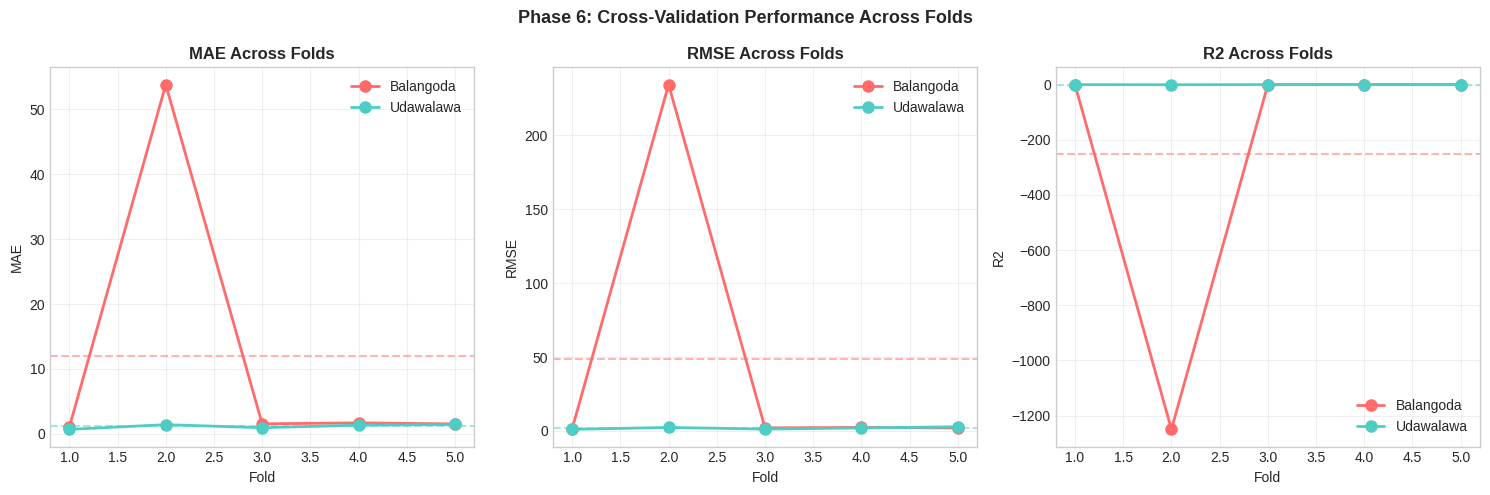

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Phase 6: Cross-Validation Performance Across Folds', fontsize=13, fontweight='bold')
colors = {'Balangoda': '#FF6B6B', 'Udawalawa': '#4ECDC4'}

for idx, metric in enumerate(['MAE', 'RMSE', 'R2']):
    ax = axes[idx]
    for moh in sorted(cv_df['MOH'].unique()):
        d = cv_df[cv_df['MOH']==moh]
        ax.plot(d['Fold'], d[metric], 'o-', label=moh, color=colors[moh], lw=2, markersize=8)
        ax.axhline(d[metric].mean(), color=colors[moh], ls='--', alpha=0.5)
    ax.set_xlabel('Fold')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} Across Folds', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('phase6_cv_results.png', dpi=300, bbox_inches='tight')
plt.show()

## 6.6 Summary Statistics

In [6]:
# Per-MOH cross-validation summary (mean and SD across folds)
summary = cv_df.groupby('MOH').agg({
    'MAE':  ['mean','std'],
    'RMSE': ['mean','std'],
    'R2':   ['mean','std']
}).round(3)
print('Cross-Validation Summary (Mean ± SD across 5 folds):')
print(summary)

cv_df.to_csv('phase6_cv_detailed_results.csv', index=False)
print('\nSaved: phase6_cv_detailed_results.csv')

for f in ['phase6_cv_detailed_results.csv','phase6_cv_results.png']:
    try:
        files.download(f)
        print(f'Downloaded: {f}')
    except Exception:
        pass


Cross-Validation Summary (Mean ± SD across 5 folds):
              MAE            RMSE                R2         
             mean     std    mean      std     mean      std
MOH                                                         
Balangoda  11.920  23.429  48.457  103.883 -250.058  558.809
Udawalawa   1.162   0.331   1.941    0.741   -0.224    0.315

Saved: phase6_cv_detailed_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: phase6_cv_detailed_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: phase6_cv_results.png
